In [53]:
import numpy as np
import pandas as pd
from obspy.core import read, UTCDateTime
from obspy.core.inventory import read_inventory
from obspy.core.util.attribdict import AttribDict
from obspy.clients.fdsn import Client
from collections import defaultdict
from obspy.geodetics import gps2dist_azimuth
from obspy.geodetics import kilometers2degrees
from scipy.fft import fft, fftfreq
from obspy.taup import TauPyModel
import matplotlib.pyplot as plt
from pystp import STPClient
from obspy.core.stream import Stream
import pickle
import copy
import json
import os

In [54]:
import sys, os, importlib
package_path = os.path.abspath('../')
if package_path not in sys.path:
    sys.path.append(package_path)
from package import functions as fn
from package import model as rm
from package import optimizer as opt
from package import plots

In [55]:
# project/data/streams_3146815.pkl
# load the stream_dict from the pickle file
with open('streams_3146815.pkl', 'rb') as f:
    stream_dict = pickle.load(f)
stream_dict

{'ISA': 3 Trace(s) in Stream:
CI.ISA..BHE | 1994-01-28T07:42:34.815004Z - 1994-01-28T07:50:51.265004Z | 20.0 Hz, 9930 samples
CI.ISA..BHN | 1994-01-28T07:44:19.467001Z - 1994-01-28T07:49:33.317001Z | 20.0 Hz, 6278 samples
CI.ISA..BHZ | 1994-01-28T07:44:33.317000Z - 1994-01-28T07:49:48.667000Z | 20.0 Hz, 6308 samples,
 'VTV': 3 Trace(s) in Stream:
CI.VTV..BHE | 1994-01-28T07:43:03.917002Z - 1994-01-28T07:49:42.667002Z | 20.0 Hz, 7976 samples
CI.VTV..BHN | 1994-01-28T07:44:04.417002Z - 1994-01-28T07:49:03.617002Z | 20.0 Hz, 5985 samples
CI.VTV..BHZ | 1994-01-28T07:44:03.217001Z - 1994-01-28T07:49:15.967001Z | 20.0 Hz, 6256 samples,
 'RPV': 3 Trace(s) in Stream:
CI.RPV..BHE | 1994-01-28T07:43:21.642000Z - 1994-01-28T07:48:13.992000Z | 20.0 Hz, 5848 samples
CI.RPV..BHN | 1994-01-28T07:43:11.942003Z - 1994-01-28T07:48:12.592003Z | 20.0 Hz, 6014 samples
CI.RPV..BHZ | 1994-01-28T07:44:04.092001Z - 1994-01-28T07:47:48.842001Z | 20.0 Hz, 4496 samples,
 'GSC': 3 Trace(s) in Stream:
CI.GSC..BHE |

In [56]:
keys = list(stream_dict.keys())
print(keys)

['ISA', 'VTV', 'RPV', 'GSC', 'PAS', 'MLAC', 'SVD', 'USC', 'SBC']


In [57]:
# sp_names = ['CALB', 'GRH', 'NHL', 'SMF', 'SYL', 'BRCY', 'CPCP', 'CWHP', 'LA00', 'PIRU', 'SFPW' ]
# print(sp_names)

# # look for matches btn keys and sp_names
# matches = [key for key in keys if key in sp_names]
# print(matches)

In [58]:
test_key = keys[3] # vs 0... 0 is an issue
st1 = copy.deepcopy(stream_dict[test_key])
print(st1)

3 Trace(s) in Stream:
CI.GSC..BHE | 1994-01-28T07:42:08.843996Z - 1994-01-28T07:50:06.793996Z | 20.0 Hz, 9560 samples
CI.GSC..BHN | 1994-01-28T07:43:19.444002Z - 1994-01-28T07:51:19.694002Z | 20.0 Hz, 9606 samples
CI.GSC..BHZ | 1994-01-28T07:42:51.743997Z - 1994-01-28T07:51:00.093997Z | 20.0 Hz, 9768 samples


In [59]:
# get location of the earthquake from the event data
stp = STPClient()
stp.connect()
event_id = 3146815 # best from other code
event = stp.get_events(evids=[event_id]).events[0]
origin = event.origins[0]
eq_lat = origin.latitude
eq_lon = origin.longitude
hdepth = origin.depth

sta_lat = st1[0].stats.sac.stla
sta_lon = st1[0].stats.sac.stlo

az = st1[0].stats.sac.az
baz = st1[0].stats.sac.baz
print(f"Azimuth: {az:.2f}, Back-Azimuth: {baz:.2f}")
event_locs = [eq_lat, eq_lon, sta_lat, sta_lon]
dist, az_check, baz_check = gps2dist_azimuth(*event_locs)
epdist = kilometers2degrees(dist/1000)

	****************************************
	*   Welcome to the Southern California *
	*      Earthquake Data Center          *
	*     Seismic Transfer Program         *
        ****************************************

Please use the following citation:
 SCEDC (2013): Southern California Earthquake Data Center.
 Caltech.Dataset. doi:10.7909/C3WD3xH
to cite data downloaded from the SCEDC.

If you use a SCEDC waveform dataset that contains data with
network codes other than 'CI', please cite the network and
its DOI. Use https://fdsn.org/networks/ to find the network
code and its corresponding DOI.

For large downloads, please consider trying the SCEDC AWS Public Dataset:
https://scedc.caltech.edu/data/cloud.html


Azimuth: 53.89, Back-Azimuth: 234.92


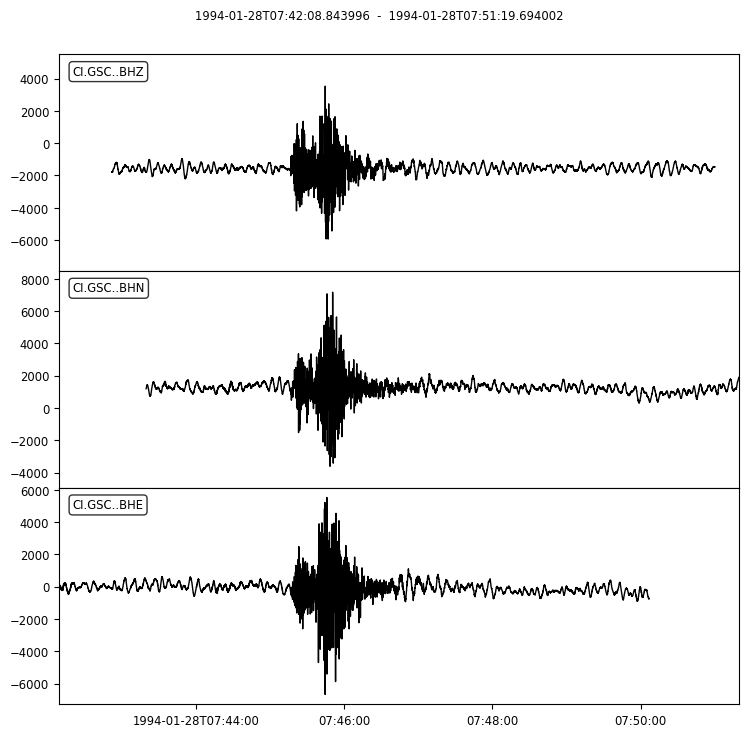

In [60]:
st1.plot();

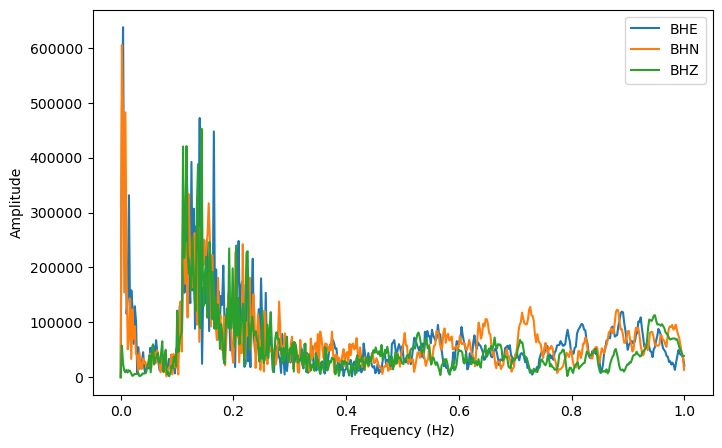

In [61]:
plt.figure(figsize=(8,5))

for tr in st1:
    data = tr.data.astype(float)
    data -= np.mean(data)

    n = len(data)
    dt = tr.stats.delta

    Y = fft(data)
    f = fftfreq(n, dt)

    mask = (f >= 0) & (f < 1)

    plt.plot(f[mask], np.abs(Y[mask]), label=tr.stats.channel)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [62]:
velocity_model = TauPyModel(model='ak135')
p_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist, phase_list=['P'])
s_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                    distance_in_degree=epdist, phase_list=['S'])

# get min time
p_arrival = min(p_arrivals, key=lambda x: x.time)
s_arrival = min(s_arrivals, key=lambda x: x.time)
p_inc = p_arrival.incident_angle
s_inc = s_arrival.incident_angle
print(f"P incident angle: {p_inc}, S incident angle: {s_inc}")

P incident angle: 45.8387291005983, S incident angle: 50.17529988873609


In [63]:
client = Client("SCEDC")
start1 = st1[0].stats.starttime
end1 = st1[0].stats.endtime
inv = client.get_stations(network="CI", station=test_key,   
                          starttime=start1, endtime=end1,
                          level="response")
print(inv)

Inventory created at 2026-07-03T19:34:25.000000Z
	Created by: SCEDC WEB SERVICE: fdsnws-station | version: 1.1
		    http://service.scedc.caltech.edu/fdsnws/station/1/query?net=CI&sta=...
	Sending institution: SCEDC (SCEDC)
	Contains:
		Networks (1):
			CI
		Stations (1):
			CI.GSC (Goldstone)
		Channels (7):
			CI.GSC..BHZ, CI.GSC..BHN, CI.GSC..BHE, CI.GSC..EHZ, CI.GSC..HLZ, 
			CI.GSC..HLN, CI.GSC..HLE


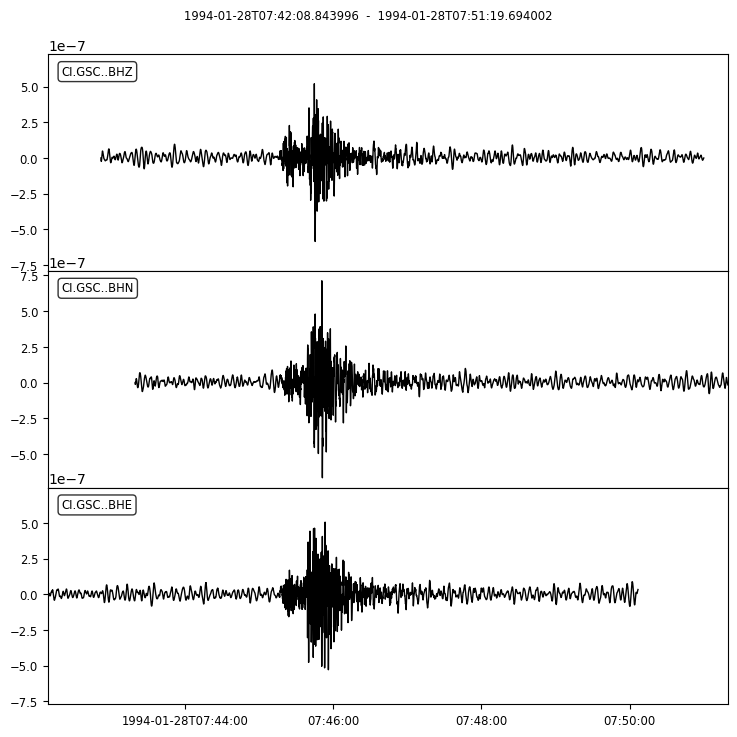

In [64]:
for tr in st1:
    tr.detrend('linear')
    tr.remove_sensitivity(inv)
    tr.filter('highpass', freq=0.3, corners=4, zerophase=False)
    tr.integrate()

st2 = copy.deepcopy(st1)

st1.plot();

#### SPLITTING POINT

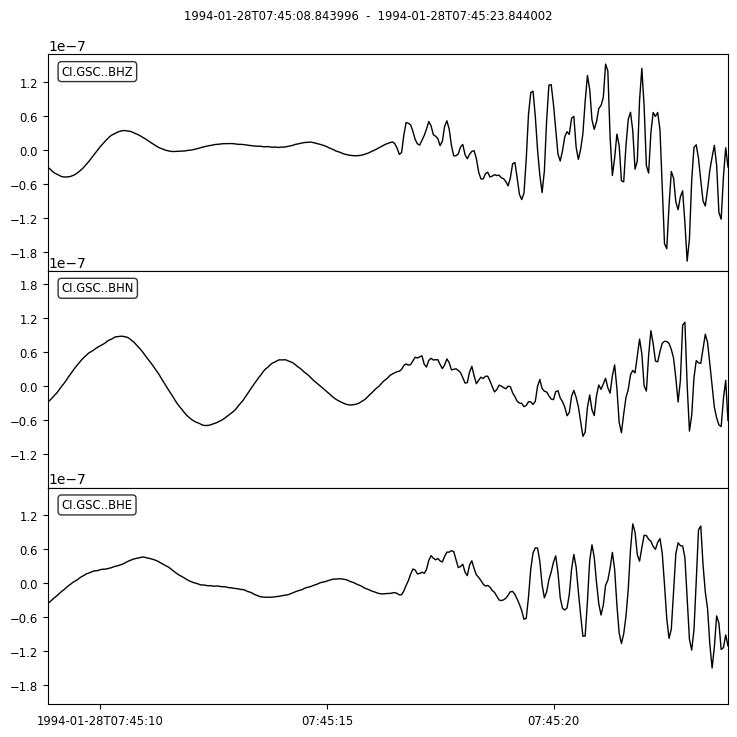

In [65]:
# zoom this into the window using trace.trim()
start1 = st1[0].stats.starttime + 180
end1 = st1[0].stats.starttime + 195
st1.trim(start1, end1)
st1.plot();

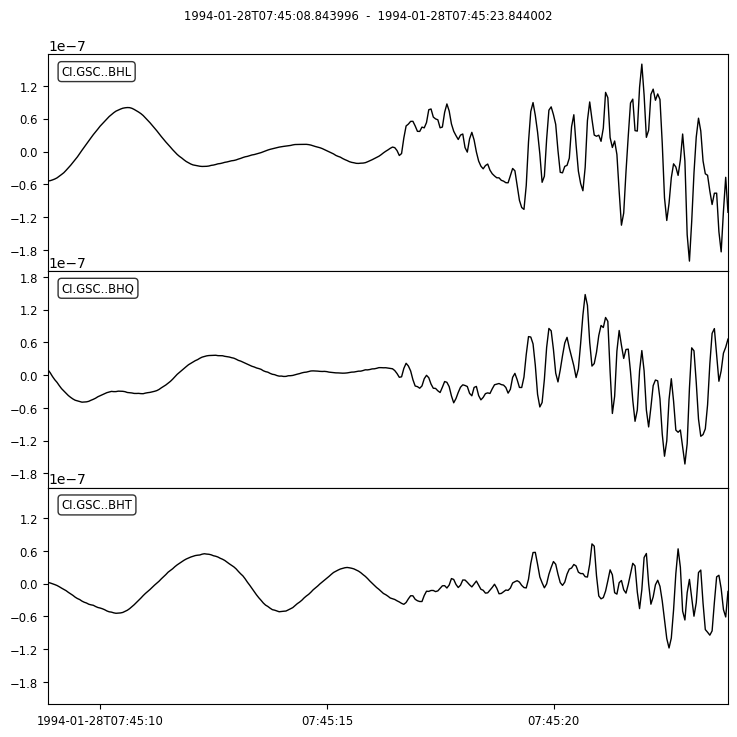

In [66]:
st1_alt = copy.deepcopy(st1)
st1_alt.rotate('ZNE->LQT', back_azimuth=baz, inclination=p_inc)
st1_alt.plot();

In [67]:
data_p = np.zeros((len(st1), len(st1[0].data)))
data_p.shape

# NOTE: be careful what order I'm using for the channels
data_p[0, :] = copy.deepcopy(st1.select(component='Z')[0])
data_p[1, :] = copy.deepcopy(st1.select(component='N')[0])
data_p[2, :] = copy.deepcopy(st1.select(component='E')[0])

R_znerzrt = fn.zne2zrt_matrix(baz, deg=True)
R_zne2lqt = fn.zrt2lqt_matrix(p_inc=p_inc, deg=True)
data_p_zrt = R_znerzrt @ data_p
data_p_lqt = R_zne2lqt @ data_p_zrt

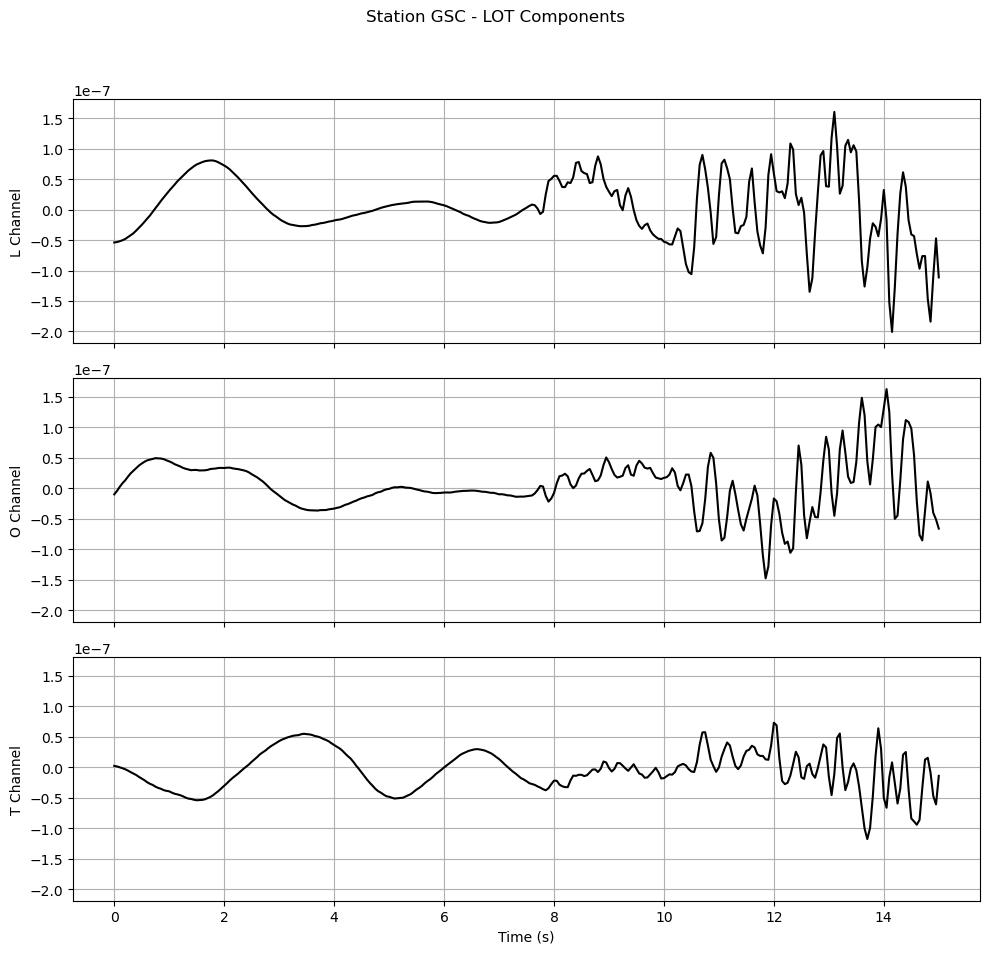

In [68]:
# make subplots of all three components L, Q, T
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=True)
components = ['L', 'Q', 'T']
ylims = [np.min(data_p_lqt), np.max(data_p_lqt)]

# add 10% padding to ylims
padding = 0.05 * (ylims[1] - ylims[0])
ylims[0] -= padding
ylims[1] += padding

def q2o(comp): return 'O' if comp == 'Q' else comp

for i, comp in enumerate(components):
    times = st1_alt.select(component=comp)[0].times(type='relative')
    to_plot = data_p_lqt[i,:]
    if comp == 'Q': # verify the flip on this channel
        to_match = -np.array(st1_alt.select(component=comp)[0])
        assert np.allclose(data_p_lqt[i,:], to_match), "Q component mismatch"
    else:
        to_match = np.array(st1_alt.select(component=comp)[0])
        assert np.allclose(data_p_lqt[i,:], to_match), f"{comp} component mismatch"
    axes[i].plot(times, to_plot, 'k')
    axes[i].set_ylabel(f'{q2o(comp)} Channel')
    axes[i].grid()
    axes[i].set_ylim(ylims)

# set y axis min and max for all three subplots to be the same
axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'Station {test_key} - LOT Components')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

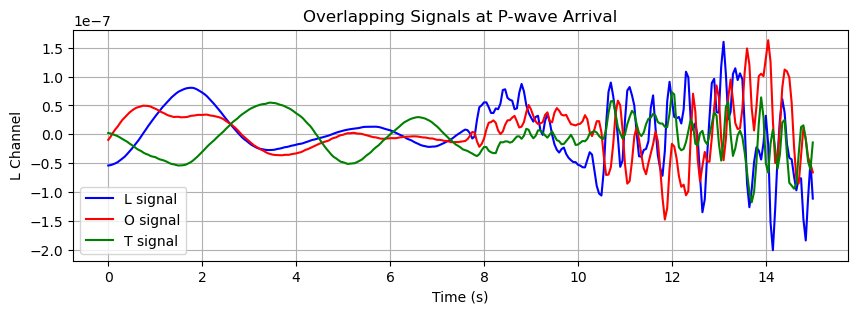

In [69]:
delta_p = st1[0].stats.delta
times_p = np.arange(0, len(st1[0].data)) * delta_p

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(times_p, data_p_lqt[0,:], 'b', label='L signal')
ax.plot(times_p, data_p_lqt[1,:], 'r', label='O signal')
ax.plot(times_p, data_p_lqt[2,:], 'g', label='T signal')
ax.legend()
ax.set_xlabel('Time (s)')
ax.set_ylabel('L Channel')
ax.grid()
plt.title('Overlapping Signals at P-wave Arrival')
plt.show()

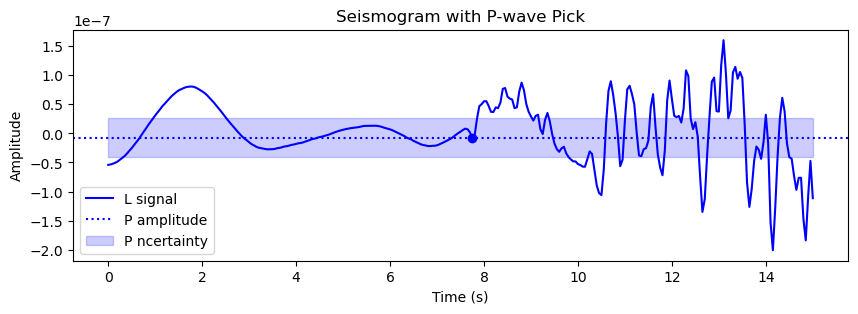

In [70]:
p_pick = 7.6
p_index = int(p_pick/delta_p)
half_window = int(0.2/delta_p)
p_unc_pick = 7.5
p_unc_index = int(p_unc_pick/delta_p)

zoomed_data_p = data_p_lqt[:, p_index - half_window:p_index + half_window+1]

# get the index of the min value in zoomed data, but in original data
min_index_p = p_index - half_window + np.argmin(zoomed_data_p[0, :])
p_amp = data_p_lqt[0, min_index_p]
p_std = np.std(data_p_lqt[0, :p_unc_index])

# plot the seismogram with the picked point
# plt.figure(figsize=(10, 3))
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_title('Seismogram with P-wave Pick')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.plot(times_p, data_p_lqt[0,:], 'b', label='L signal')
ax.plot(times_p[min_index_p], p_amp, 'bo')
ax.axhline(y=p_amp, color='blue', linestyle=':', label='P amplitude')
ax.fill_between(times_p, p_amp - p_std, p_amp + p_std, color='blue', alpha=0.2, label='P ncertainty')
ax.legend()
plt.show()

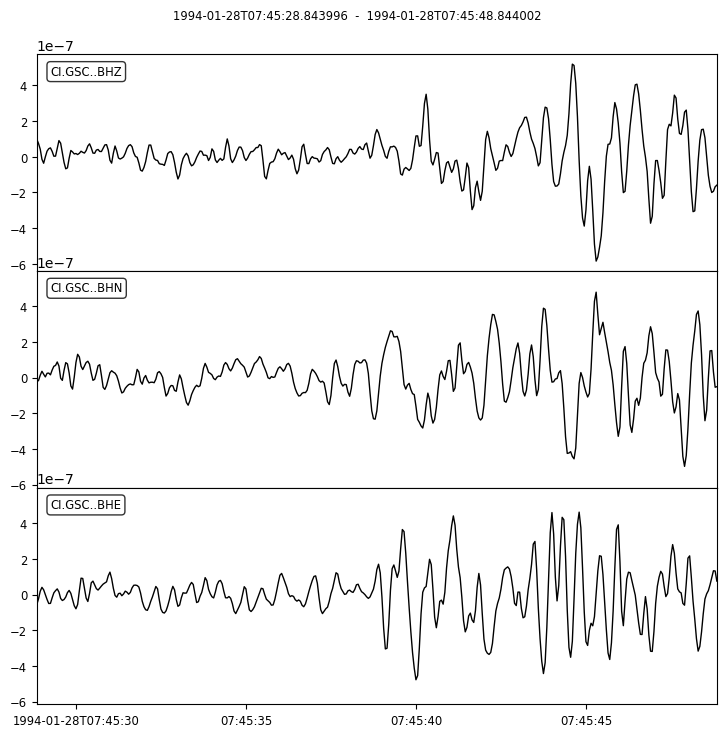

In [71]:
# zoom this into the window using trace.trim()
start2 = st2[0].stats.starttime + 200
end2 = st2[0].stats.starttime + 220
st2.trim(start2, end2)
st2.plot();

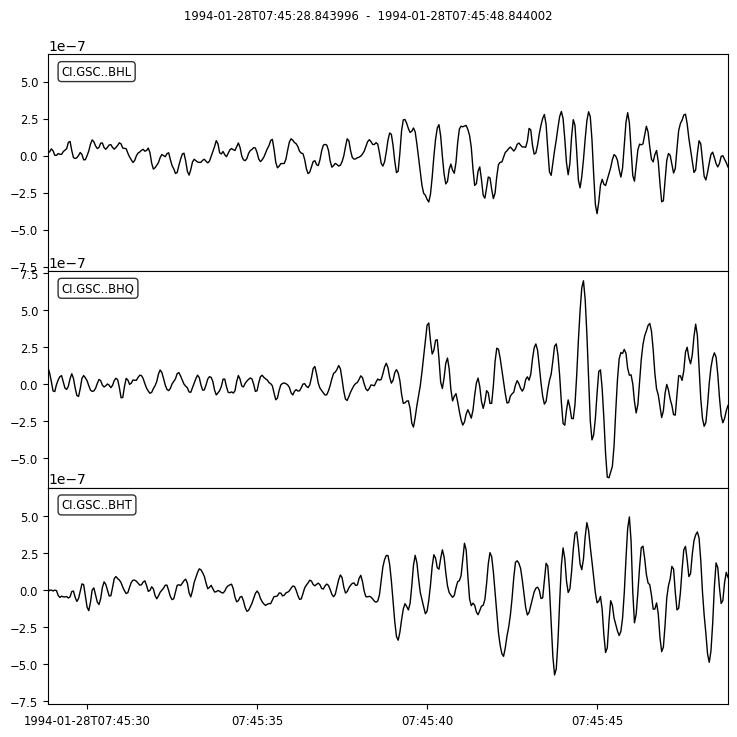

In [72]:
st2_alt = copy.deepcopy(st2)
st2_alt.rotate('ZNE->LQT', back_azimuth=baz, inclination=s_inc)
st2_alt.plot();

In [73]:
data_s = np.zeros((len(st2), len(st2[0].data)))
data_s.shape

# NOTE: be careful what order I'm using for the channels
data_s[0, :] = copy.deepcopy(st2.select(component='Z')[0])
data_s[1, :] = copy.deepcopy(st2.select(component='N')[0])
data_s[2, :] = copy.deepcopy(st2.select(component='E')[0])

R_znerzrt = fn.zne2zrt_matrix(baz, deg=True)
R_zne2lqt = fn.zrt2lqt_matrix(s_inc=s_inc, deg=True)
data_s_zrt = R_znerzrt @ data_s
data_s_lqt = R_zne2lqt @ data_s_zrt

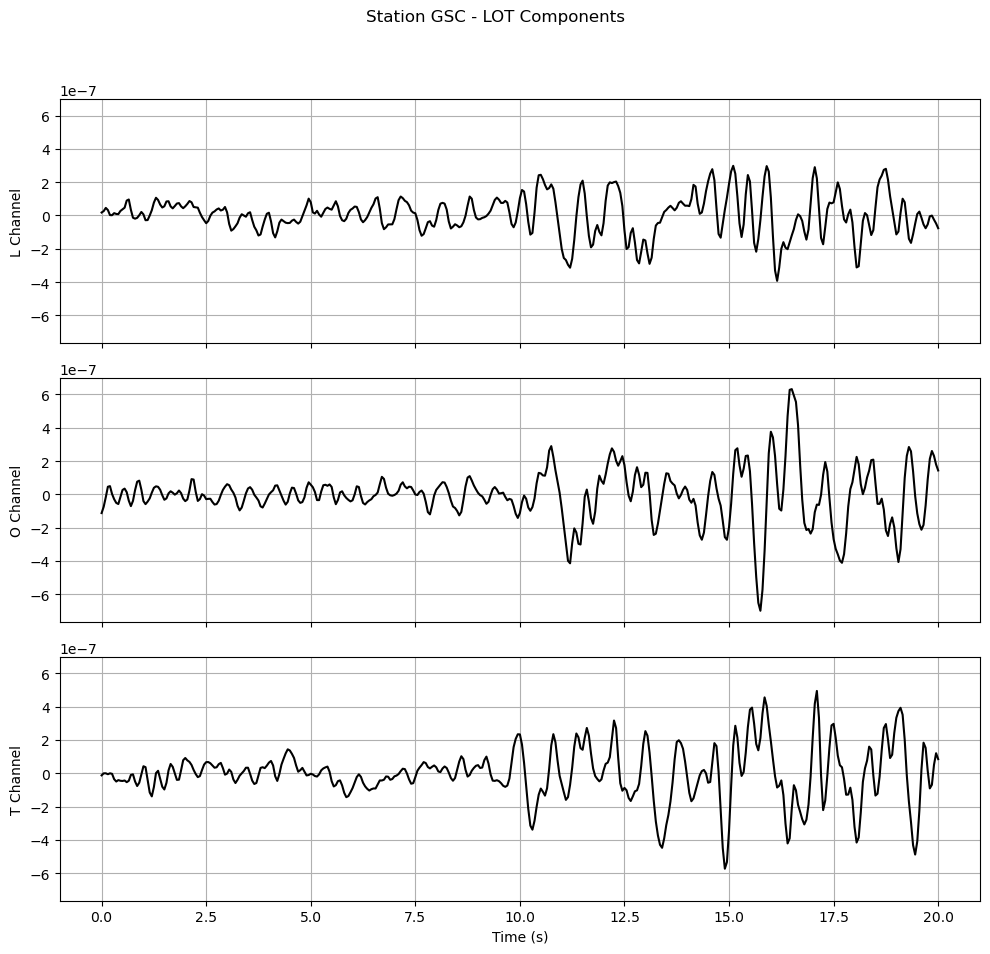

In [74]:
# make subplots of all three components L, Q, T
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=True)
components = ['L', 'Q', 'T']
ylims = [np.min(data_s_lqt), np.max(data_s_lqt)]

# add 10% padding to ylims
padding = 0.05 * (ylims[1] - ylims[0])
ylims[0] -= padding
ylims[1] += padding

for i, comp in enumerate(components):
    times = st2_alt.select(component=comp)[0].times(type='relative')
    to_plot = data_s_lqt[i,:]
    if comp == 'Q': # verify the flip on this channel
        to_match = -np.array(st2_alt.select(component=comp)[0])
        assert np.allclose(data_s_lqt[i,:], to_match, atol=1e-4), f"Q comp mismatch"
    else:
        to_match = np.array(st2_alt.select(component=comp)[0])
        assert np.allclose(data_s_lqt[i,:], to_match, atol=1e-4), f"{comp} comp mismatch"
    axes[i].plot(times, to_plot, 'k')
    axes[i].set_ylabel(f'{q2o(comp)} Channel')
    axes[i].grid()
    axes[i].set_ylim(ylims)

# set y axis min and max for all three subplots to be the same
axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'Station {test_key} - LOT Components')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

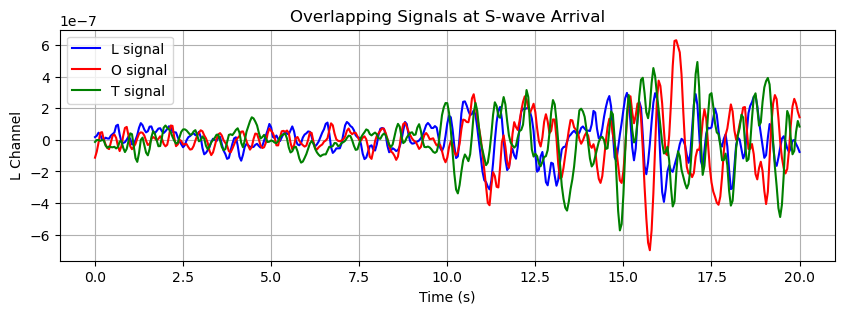

In [75]:
delta_s = st2[0].stats.delta
times_s = np.arange(0, len(st2[0].data)) * delta_s

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(times_s, data_s_lqt[0,:], 'b', label='L signal')
ax.plot(times_s, data_s_lqt[1,:], 'r', label='O signal')
ax.plot(times_s, data_s_lqt[2,:], 'g', label='T signal')
ax.legend()
ax.set_xlabel('Time (s)')
ax.set_ylabel('L Channel')
ax.grid()
plt.title('Overlapping Signals at S-wave Arrival')
plt.show()

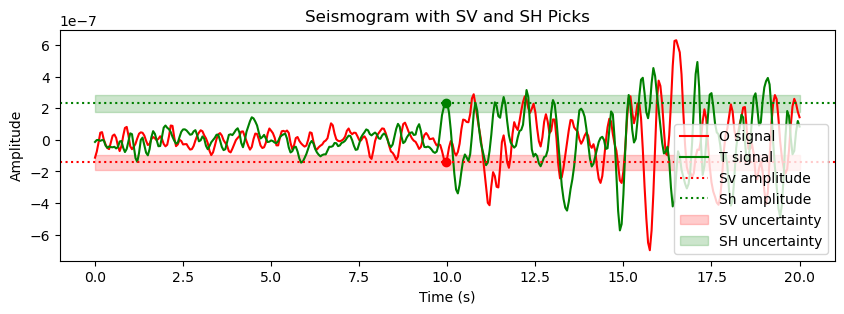

In [76]:
s_pick = 10.0
s_index = int(s_pick/delta_s)
half_window = int(0.2/delta_s)
s_unc_pick = 9.5
s_unc_index = int(s_unc_pick/delta_s)

zoomed_data_s = data_s_lqt[:, s_index - half_window:s_index + half_window+1]

# get the index of the min value in zoomed data, but in original data
min_index_sv = s_index - half_window + np.argmin(zoomed_data_s[1, :])
min_index_sh = s_index - half_window + np.argmax(zoomed_data_s[2, :])
sv_amp = data_s_lqt[1, min_index_sv]
sh_amp = data_s_lqt[2, min_index_sh]
sv_std = np.std(data_s_lqt[1, :s_unc_index])
sh_std = np.std(data_s_lqt[2, :s_unc_index])

# plot the seismogram with the picked point
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_title('Seismogram with SV and SH Picks')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.plot(times_s, data_s_lqt[1,:], 'r', label='O signal')
ax.plot(times_s, data_s_lqt[2,:], 'g', label='T signal')
ax.plot(times_s[min_index_sv], sv_amp, 'ro')
ax.plot(times_s[min_index_sh], sh_amp, 'go')
ax.axhline(y=sv_amp, color='red', linestyle=':', label='Sv amplitude')
ax.axhline(y=sh_amp, color='green', linestyle=':', label='Sh amplitude')
ax.fill_between(times_s, sv_amp - sv_std, sv_amp + sv_std, color='red', alpha=0.2, label='SV uncertainty')
ax.fill_between(times_s, sh_amp - sh_std, sh_amp + sh_std, color='green', alpha=0.2, label='SH uncertainty')
ax.legend()
plt.show()

In [77]:
# collect amplitudes and uncertainties
observed_amp = np.array([p_amp, sv_amp, sh_amp])
observed_unc = np.array([p_std, sv_std, sh_std])

# optional: scale factor for std (regularization)
# scale_factor = 1/np.linalg.norm(observed_amp)
scale_factor = 1.0

# collect other necessary information for the inversion
takeoff_angles = [p_arrival.takeoff_angle, s_arrival.takeoff_angle]

# get alpha and beta from the velocity model
vel_model_path = 'AK135_lookup.csv'
lookup_table = pd.read_csv(vel_model_path)
velocities = fn.extract_velocities(lookup_table, hdepth)

# get epicentral distance, azimuth, and depth
epdist_1 = epdist  # degrees
azimuth_1 = az # degrees
hdepth_1 = hdepth # km

# benchark relative to the skhash output for this id
benchmark_sdr = np.array([147.8,41.8,139.2]) # degrees

# benchmark prediction:
benchmark_amp = np.array([0.02173537, 0.12125203, 0.99238376])
cossim = fn.unit_vec(observed_amp) @ fn.unit_vec(benchmark_amp)

# print all arguments in a list
print(f"Observed Amplitudes: {observed_amp} m")
print(f"Observed Uncertainties: {observed_unc} m")
print(f"Scale Factor: {scale_factor}")
print(f"Takeoff Angles: {takeoff_angles} deg")
print(f"Velocities: {velocities} m/s")
print(f"Epicentral Distance: {epdist_1} deg")
print(f"Azimuth: {azimuth_1} deg")
print(f"Depth: {hdepth_1} km")
print(f"Benchmark SDR: {benchmark_sdr} deg")
print(f"Benchmark Amplitudes: {benchmark_amp}")
print(f"Relative Amplitudes: {fn.unit_vec(observed_amp)}")
print(f"Cosine Similarity: {cossim}")
print(f"Station name: {test_key}")

Observed Amplitudes: [-7.29231505e-09 -1.41614536e-07  2.33567343e-07] m
Observed Uncertainties: [3.30160873e-08 4.75339096e-08 5.40351764e-08] m
Scale Factor: 1.0
Takeoff Angles: [53.761310515570834, 59.01894116696761] deg
Velocities: [6.5  3.85] m/s
Epicentral Distance: 1.831800545005885 deg
Azimuth: 53.88997268676758 deg
Depth: 20.53 km
Benchmark SDR: [147.8  41.8 139.2] deg
Benchmark Amplitudes: [0.02173537 0.12125203 0.99238376]
Relative Amplitudes: [-0.02668805 -0.51827386  0.85479819]
Cosine Similarity: 0.7848660085071874
Station name: GSC


### INVERSION

In [78]:
# initialize model
radiation_model_1 = rm.RadiationModel(np.deg2rad(azimuth_1), takeoff_angles,
                                      velocities)
radiation_model_1.set_Ao(observed_amp)
radiation_model_1.set_Uo(observed_unc*scale_factor)
radiation_model_1.set_real_sdr(np.deg2rad(benchmark_sdr))

# tune hyperparameters for optimization
config = opt.get_config()

# multistart optimization
num_starts =50
starts = fn.random_params(num_starts)

radiation_model_1.reset()
print_every = 10

for index, start in enumerate(starts):
    if print_every > 0 and index % print_every == 0:
        print(f'Run {index} of {num_starts}')
    opt.minimize(radiation_model_1, config, start)

print(f'Convergence rate: {radiation_model_1.get_convergence_rate():.0f}%')

Using sdr parameters.
Run 0 of 50
Run 10 of 50
Run 20 of 50
Run 30 of 50
Run 40 of 50
Convergence rate: 68%


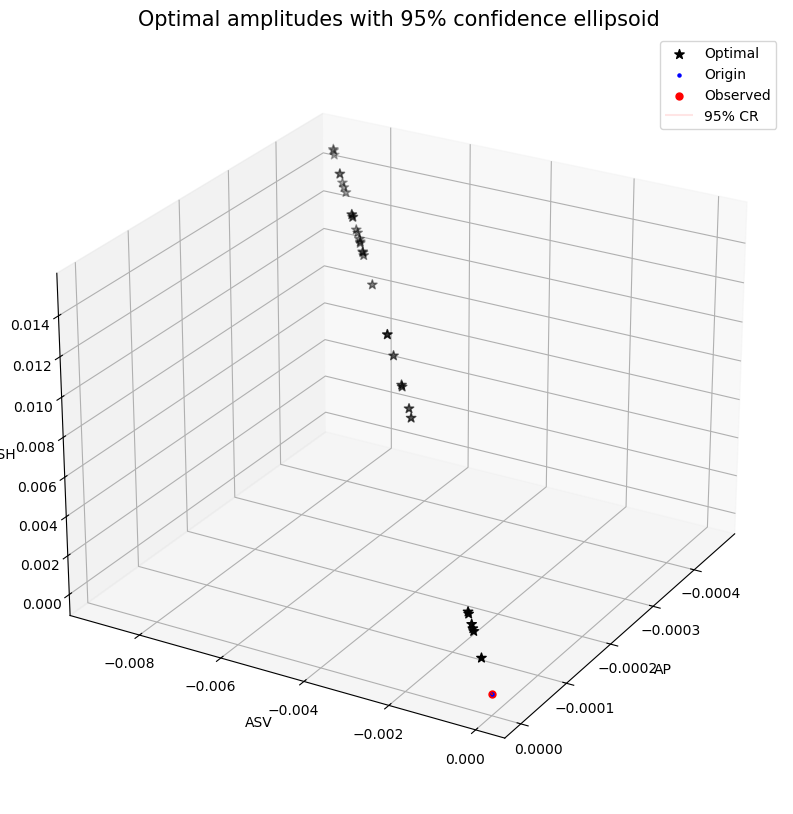

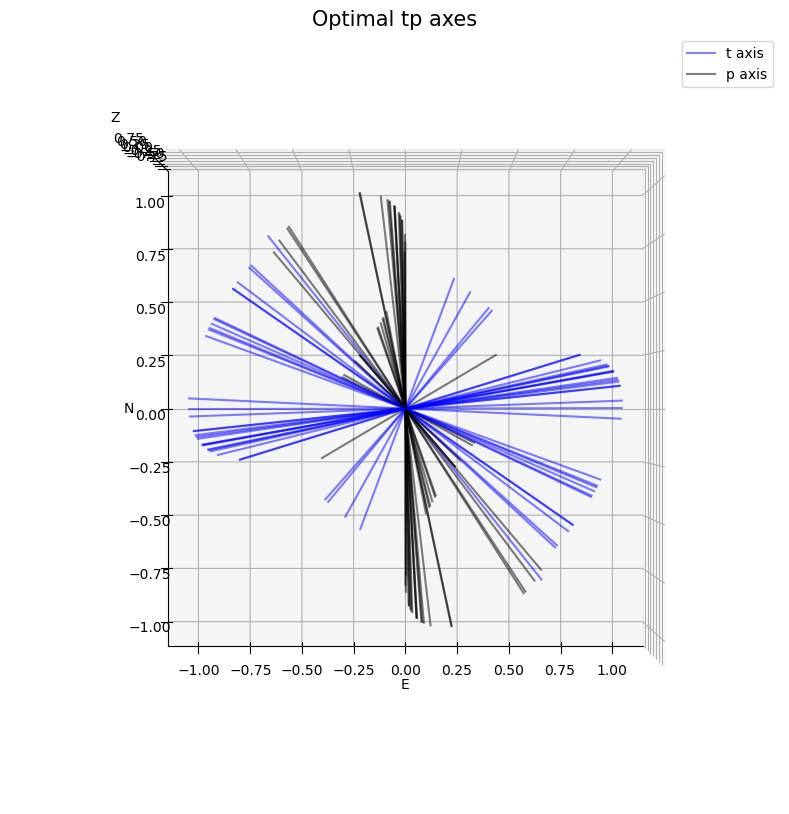

Entering function for 2d iterate plot
Checkpoint 1
Checkpoint 2


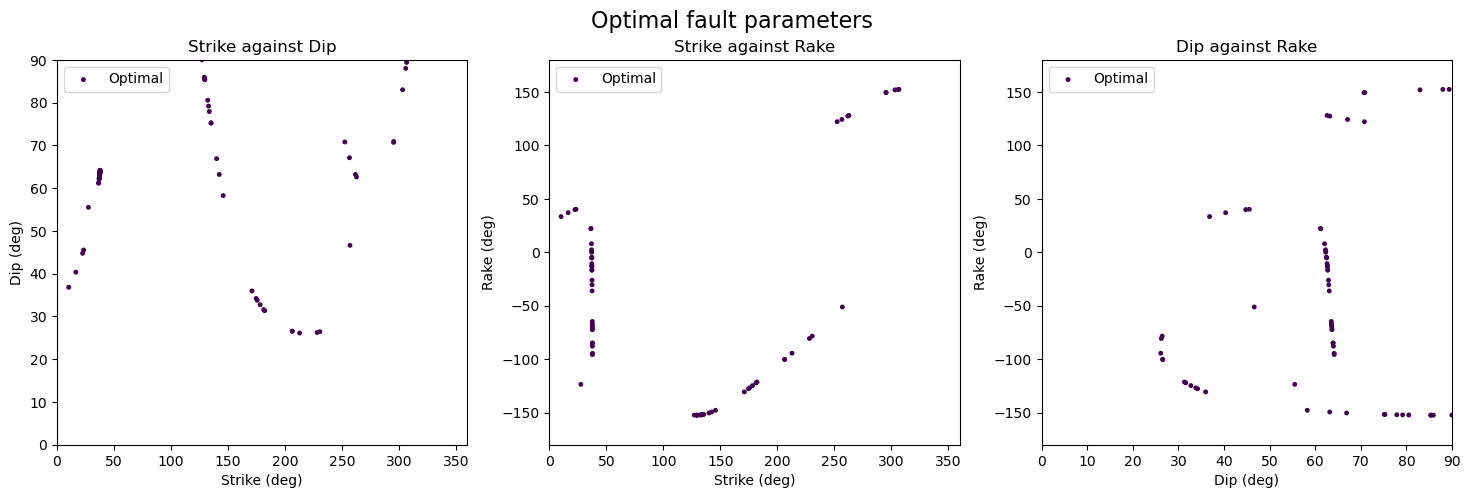

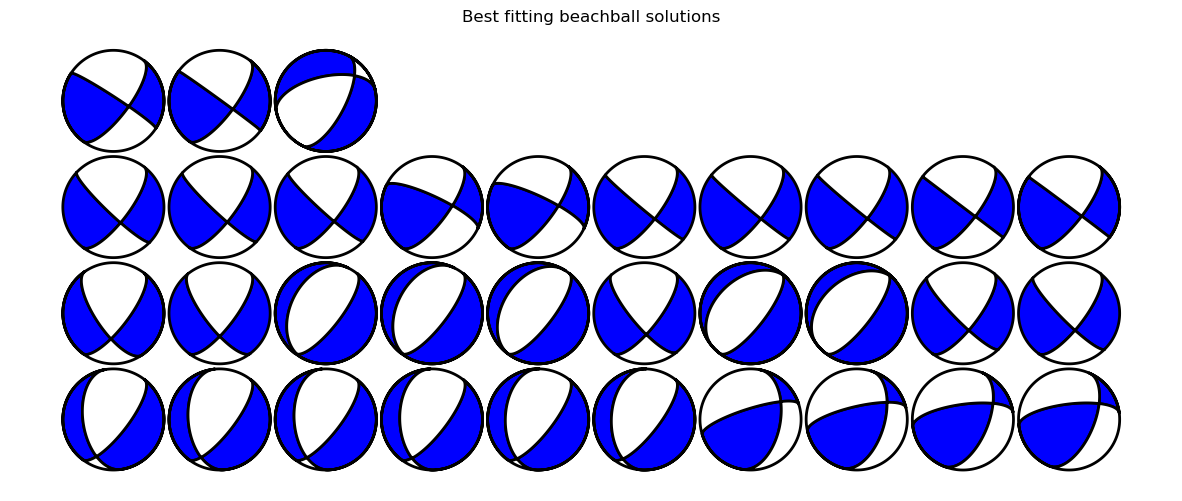

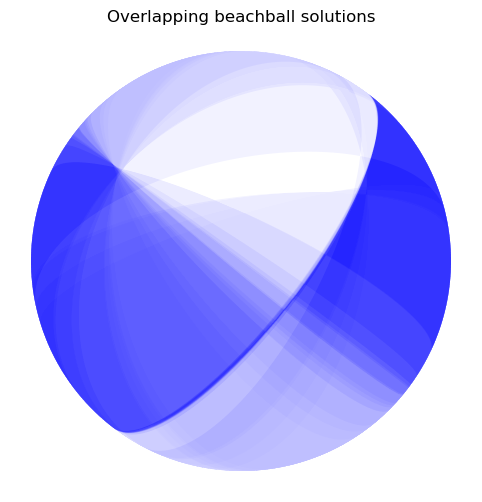

In [79]:
# amplitude plot
radiation_model_1.reset_grid_amplitudes()
radiation_model_1.set_grid_amplitudes(7, random=False, fix_params=False)
plots.amplitudes(radiation_model_1, azim=30, elev=25, s=50, alpha=0.5,
                 iterates=False, grid=False, cross_section=[0,0,0],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                    uncertainty=True, conf=0.95)

# tp axis plot
plots.tp_axes(radiation_model_1, azim=-90, elev=90, half=False)

# 2D iterates plot
plots.iterates_2D(radiation_model_1, s=25, optimal=True, index=2, cmap='viridis')

# beachball plots
plots.beachballs(radiation_model_1, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(15,10), overlap=False, original=False)
# NOTE: can original be true in previous work? What's different?

# overlapping beachball plot
plots.beachballs(radiation_model_1, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=False)